# Introduction to Machine Learning

## Practice class 03 - Ensamble methhods

**Introduction**
Ensamble methods are combine together models in the aim of better performance. 

**What can be an ensamble?**
* different algorithms
* different choice of hyperparameters
* different training data
* training data with different weight

We are going to review two different concepts:
* **Bagging:** Train using independent random subsets of data
* **Boosting:** Sequential training of classifiers focusing on previously misclassified data

### Demo - Bagging
The task is to fit the red curve based on the blue points. For that we are create a bag of 10 points as a random choice from the original data, and apply a curve fit. We assume that the expected function is a third order polinomial. 

We repeat the process many times and consider the ensamble of the outputs from the many different bags. 

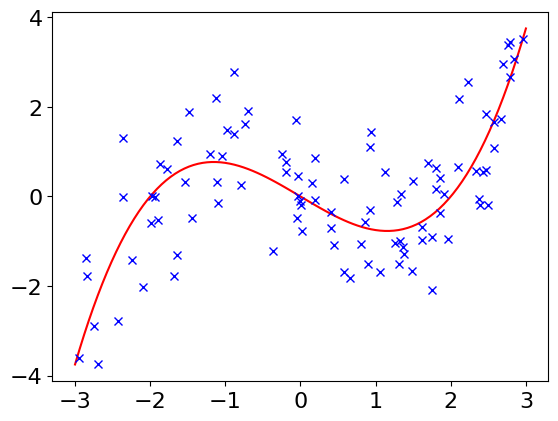

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams
rcParams['font.size'] = 16

# Generate a curve
x = np.linspace(-3,3,100)
y = 1/4*x**3-x
plt.plot(x,y, 'r-')

# Generate a random points
np.random.seed(12345)
x0 = np.random.uniform(-3,3,size=100)
y0 = 1/4*x0**3-x0 + np.random.normal( loc=0, scale=1, size=100)
plt.plot(x0,y0,'bx')

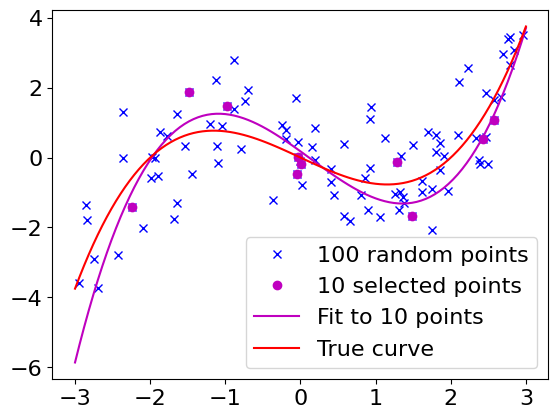

In [2]:
#pick 10 random points from the data
idx = np.random.choice(100,10)
x1 = x0[idx]
y1 = y0[idx]
plt.plot(x0,y0,'bx',label='100 random points')
plt.plot(x1,y1,'mo',label='10 selected points')

# Fit a curve to the 10 points
p = np.polyfit(x1,y1,3)
y1_fit = np.polyval(p,x)
plt.plot(x,y1_fit,'m-',label='Fit to 10 points')
plt.plot(x,y, 'r-',label='True curve')
plt.legend()


The mean of the fitted values at x=0 is 0.12867232744339738
The standard deviation of the fitted values at x=0 is 0.6078036133907737


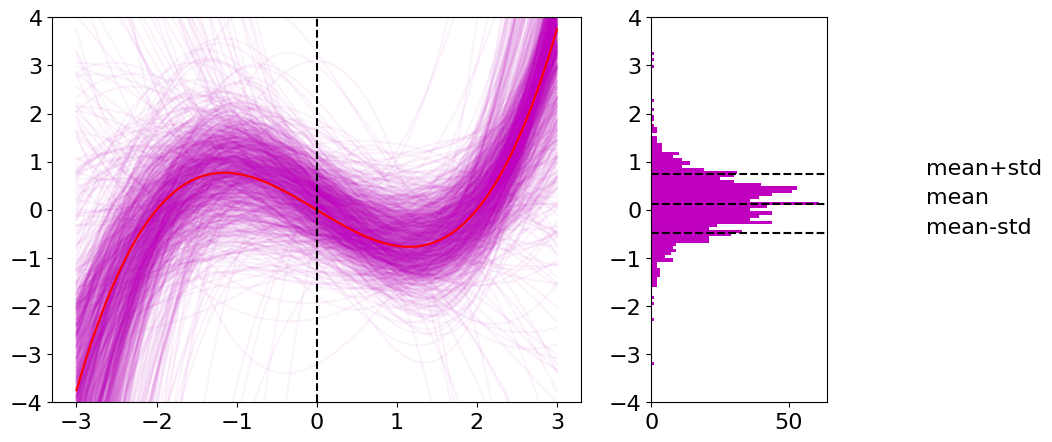

In [3]:
# repeat it N times
N = 1000
p = np.zeros((N,4))

fig,ax = plt.subplots(1,2,figsize=(10,5),width_ratios=[3,1])
for i in range(N):
    idx = np.random.choice(100,10)
    p[i] = np.polyfit(x0[idx],y0[idx],3)
    y1_fit = np.polyval(p[i],x)
    ax[0].plot(x,y1_fit,'m-',alpha=0.05)
ax[0].plot(x,y, 'r-')
ax[0].set_ylim(-4,4)
ax[0].axvline(0, color='k', linestyle='--')

# plot a histogram of the fitted values at x=0
ax[1].hist(p[:,-1],bins=100,orientation='horizontal',color='m')
ax[1].set_ylim(-4,4)

mean = np.mean(p[:,-1])
std = np.std(p[:,-1])
ax[1].axhline(mean, color='k', linestyle='--')
ax[1].axhline(mean+std, color='k', linestyle='--')
ax[1].axhline(mean-std, color='k', linestyle='--')
ax[1].text(100,mean,'mean')
ax[1].text(100,mean+std,'mean+std')
ax[1].text(100,mean-std,'mean-std')
print('The mean of the fitted values at x=0 is',mean)
print('The standard deviation of the fitted values at x=0 is',std)

**Take home messeges:**
* Reduces the variance
* The bias is not changed
* parallel


### Demo - Adaboost
The task is to classify the '+' and '-' signs with single cuts, using a single layer desision tree.

1. At each iteration reweight training data by assigning larger weight to missclassified data.
2. Train the classifier again.
3. Add the classifier to the ensamble.
4. Go to 1.

Based on the the work of Sefik Ilkin Serengil <a href="https://sefiks.com/2018/11/02/a-step-by-step-adaboost-example/">https://sefiks.com/2018/11/02/a-step-by-step-adaboost-example/</a>



In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay

In [5]:
# load the data from the file
data = np.genfromtxt("adaboost.txt",skip_header=1,delimiter=',')
X = data[:,:2]
y = np.array(data[:,2],dtype=int)

# initialize the weights
w = np.ones(len(y))/len(y)

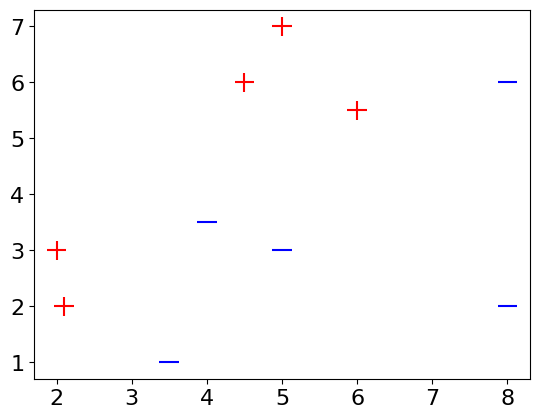

In [6]:
#plot the original data
cond = y == 1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='+', s=2e4*w[cond]**2, c='red')
cond = y == -1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='_', s=2e4*w[cond]**2, c='blue')

[Text(0.5, 0.75, 'x[0] <= 2.8\nentropy = 1.0\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'entropy = 0.954\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

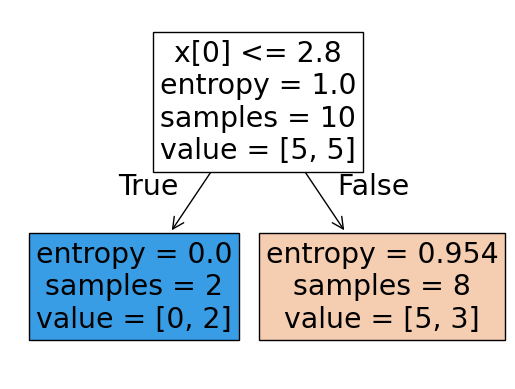

In [7]:
# fit the first classifier
clf1 = DecisionTreeClassifier(max_depth=1,criterion='entropy')
clf1.fit(X,y)
plot_tree(clf1,filled=True)

<Figure size 640x480 with 0 Axes>

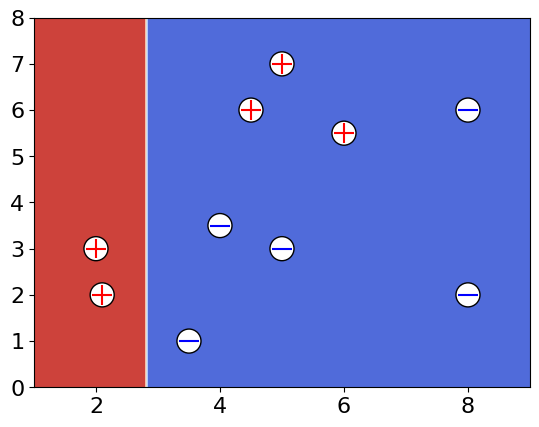

In [8]:
# plot the decision boundary
plt.figure()
DecisionBoundaryDisplay.from_estimator(
        clf1,
        X,
        cmap=plt.cm.coolwarm,
        response_method="predict",
    )

# plot the data scaled by the weights
cond = y == 1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='o', s=3e4*w[cond]**2, ec='k',fc='w')
plt.scatter(X[:,0][cond],X[:,1][cond], marker='+', s=2e4*w[cond]**2, c='red')

cond = y == -1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='o', s=3e4*w[cond]**2, ec='k',fc='w')
plt.scatter(X[:,0][cond],X[:,1][cond], marker='_', s=2e4*w[cond]**2, c='blue')

In [9]:
# the error of the first classifier
err_1 = (w*(clf1.predict(X)!=y)).sum()
err_1

0.30000000000000004

In [10]:
# the classifier coefficient
alpha_1 = 0.5*np.log((1-err_1)/err_1)
alpha_1

0.4236489301936017

In [11]:
# update the weights
w += w*np.exp(-alpha_1*y*clf1.predict(X))
w /= w.sum() # normalize the weights
w

array([0.08633658, 0.08633658, 0.13188131, 0.08633658, 0.08633658,
       0.13188131, 0.08633658, 0.13188131, 0.08633658, 0.08633658])

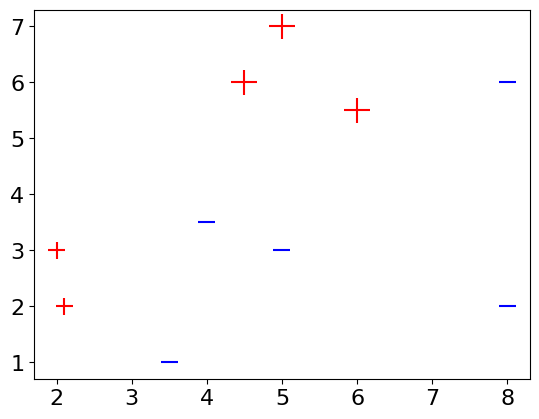

In [12]:
# plot the data scaled by the weights
cond = y == 1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='+', s=2e4*w[cond]**2, c='red')

cond = y == -1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='_', s=2e4*w[cond]**2, c='blue')

[Text(0.5, 0.75, 'x[0] <= 7.0\nentropy = 0.986\nsamples = 10\nvalue = [0.432, 0.568]'),
 Text(0.25, 0.25, 'entropy = 0.897\nsamples = 8\nvalue = [0.259, 0.568]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'entropy = -0.0\nsamples = 2\nvalue = [0.173, 0.0]'),
 Text(0.625, 0.5, '  False')]

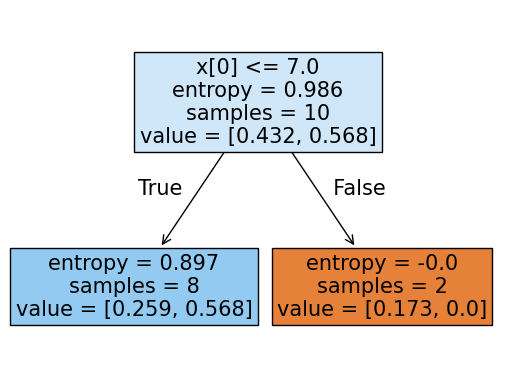

In [13]:
# fit the second classifier
clf2 = DecisionTreeClassifier(max_depth=1,criterion='entropy')
clf2.fit(X,y, sample_weight=w)
plot_tree(clf2,filled=True)

<Figure size 640x480 with 0 Axes>

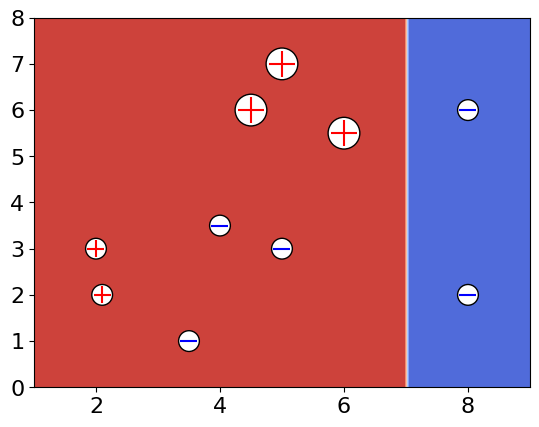

In [14]:
plt.figure()
DecisionBoundaryDisplay.from_estimator(
        clf2,
        X,
        cmap=plt.cm.coolwarm,
        response_method="predict",
    )
cond = y == 1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='o', s=3e4*w[cond]**2, ec='k',fc='w')
plt.scatter(X[:,0][cond],X[:,1][cond], marker='+', s=2e4*w[cond]**2, c='red')
cond = y == -1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='o', s=3e4*w[cond]**2, ec='k',fc='w')
plt.scatter(X[:,0][cond],X[:,1][cond], marker='_', s=2e4*w[cond]**2, c='blue')

In [15]:
# calculate the error of the second classifier
err_2 = (w*(clf2.predict(X)!=y)).sum()
err_2

0.25900974696901713

In [16]:
# calculate the classifier coefficient
alpha_2 = 0.5*np.log((1-err_2)/err_2)
alpha_2

0.525560888664397

In [17]:
# update the weights
w += w*np.exp(-alpha_2*y*clf2.predict(X))
w /= w.sum() # normalize the weights
w

array([0.07322361, 0.07322361, 0.11185091, 0.12385094, 0.12385094,
       0.11185091, 0.12385094, 0.11185091, 0.07322361, 0.07322361])

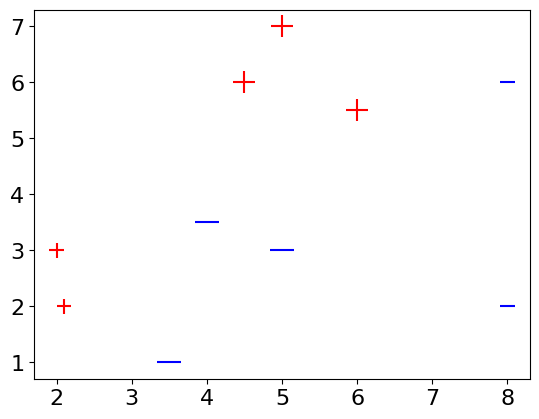

In [18]:
cond = y == 1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='+', s=2e4*w[cond]**2, c='red')
cond = y == -1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='_', s=2e4*w[cond]**2, c='blue')

[Text(0.5, 0.75, 'x[1] <= 4.5\nentropy = 0.999\nsamples = 10\nvalue = [0.518, 0.482]'),
 Text(0.25, 0.25, 'entropy = 0.808\nsamples = 6\nvalue = [0.445, 0.146]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'entropy = 0.678\nsamples = 4\nvalue = [0.073, 0.336]'),
 Text(0.625, 0.5, '  False')]

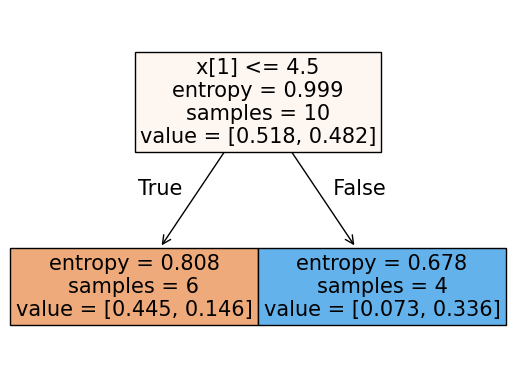

In [19]:
# fit the third classifier
clf3 = DecisionTreeClassifier(max_depth=1,criterion='entropy')
clf3.fit(X,y, sample_weight=w)
plot_tree(clf3,filled=True)

<Figure size 640x480 with 0 Axes>

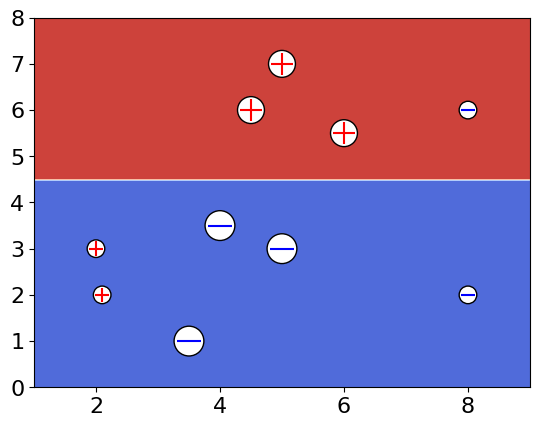

In [20]:
plt.figure()
DecisionBoundaryDisplay.from_estimator(
        clf3,
        X,
        cmap=plt.cm.coolwarm,
        response_method="predict",
    )
cond = y == 1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='o', s=3e4*w[cond]**2, ec='k',fc='w')
plt.scatter(X[:,0][cond],X[:,1][cond], marker='+', s=2e4*w[cond]**2, c='red')
cond = y == -1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='o', s=3e4*w[cond]**2, ec='k',fc='w')
plt.scatter(X[:,0][cond],X[:,1][cond], marker='_', s=2e4*w[cond]**2, c='blue')

In [21]:
# calculate the error of the third classifier
err_3 = (w*(clf3.predict(X)!=y)).sum()
err_3

0.21967082667647347

In [22]:
# calculate the classifier coefficient
alpha_3 = 0.5*np.log((1-err_3)/err_3)
alpha_3

0.6337928321283368

In [23]:
alpha_1,alpha_2,alpha_3

(0.4236489301936017, 0.525560888664397, 0.6337928321283368)

In [24]:
(alpha_1 * clf1.predict(X) + alpha_2 * clf2.predict(X) + alpha_3 * clf3.predict(X) )> 0

array([ True,  True,  True, False, False,  True, False,  True, False,
       False])

In [25]:
y>0

array([ True,  True,  True, False, False,  True, False,  True, False,
       False])

Unfortunately Decision boundary function cannot handle ensemble of models, so we have to do it by ourselfs

In [26]:
xm = np.array(np.linspace(1,9,100))
ym = np.array(np.linspace(0,8,100))
Xm, Ym = np.meshgrid(xm, ym)

In [27]:
Xgrid = np.column_stack([Xm.flatten(),Ym.flatten()])
ygrid = (alpha_1 * clf1.predict(Xgrid) + alpha_2 * clf2.predict(Xgrid) + alpha_3 * clf3.predict(Xgrid) )> 0

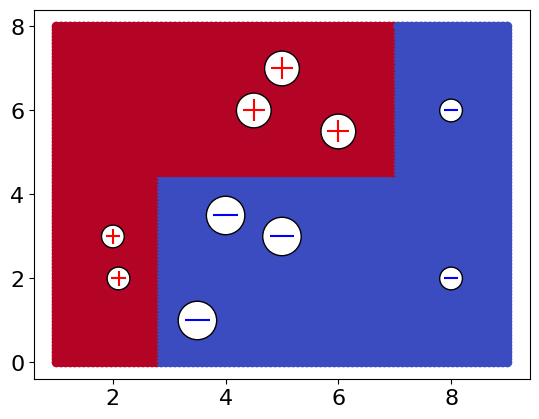

In [28]:
plt.scatter(Xgrid[:,0],Xgrid[:,1],c=ygrid,cmap='coolwarm')
plt.scatter(X[:,0],X[:,1], marker='o', facecolors='w', edgecolors='k', s=5e4*w**2)
cond = y == 1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='+', s=2e4*w[cond]**2, c='red')
cond = y == -1
plt.scatter(X[:,0][cond],X[:,1][cond], marker='_', s=2e4*w[cond]**2, c='blue')


### Task 1 - Compare bagged decision trees and random forests

Ensamble methods appeared to be useful to decrease the bias or the variance of the predictions compared to single models. Compare the behaviour of bagged decision trees and random forests, to see how they perform compared to each other. Do it both for the iris and the penguin datasets. The data is loaded and prepared for the experiment, also the train and test datasets are initialized for you.

1. Apply one-hot encoding for the `y_test` array, this is going to be your `true_pobabilities` array encoding the exact probabilites related to each datapoint of your test data. 
2. Calculate the probabilites related to the different classes as $n_i/n_\text{all}$, where $n_i$ is the number of elements of each feature in the test dataset.
3. Create a `BaggingClassifier` and a `RandomForestClassifier` both with `n_estimators=10` (the number of trees in the forest), `random_state=42`, `max_samples=10` (samples used for the training of the trees in the forest) and `max_depth=2`. Train and fit the classifiers. 
4. Use the `.predict_proba()` method of your classifiers to predict the probabilites of the different classies of each datapoints.
5. Calculate the bias and the variance as
$$
\text{bias}^2 = \mathbb{E}[(\mathbb{E}[h(x_\text{test})]-t)^2] \\
\text{variance} = \mathbb{E}[(h(x_\text{test})-\mathbb{E}[h(x_\text{test})])^2]
$$
6. Repeat it with `n_estimators` ranging from 1 to 50 and plot the vaiance and the bias as the number of estimators.


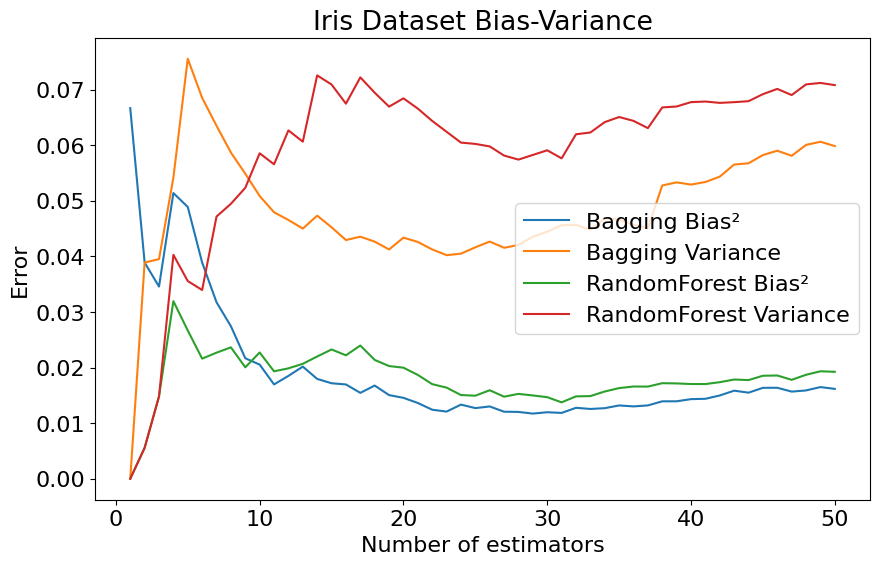

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/valida

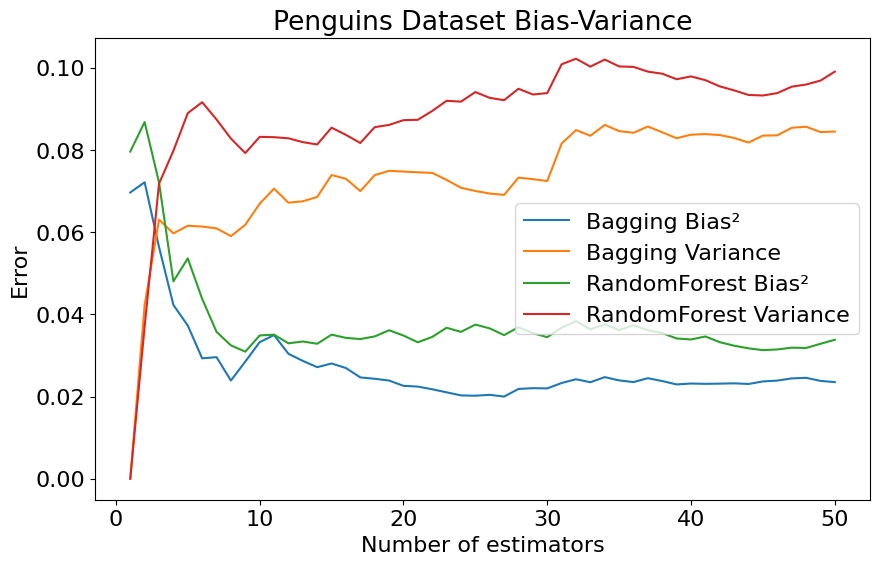

In [35]:
# import the necessary libraries
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

############################################
# Helper functions
############################################

def one_hot(y, n_classes):
    return np.eye(n_classes)[y]

def compute_bias_variance(model, X_test, true_prob):
    
    # collect predictions from individual estimators
    preds = np.array([est.predict_proba(X_test) for est in model.estimators_])
    
    # mean prediction
    mean_pred = np.mean(preds, axis=0)
    
    # bias^2
    bias = np.mean((mean_pred - true_prob) ** 2)
    
    # variance
    variance = np.mean((preds - mean_pred) ** 2)
    
    return bias, variance


def experiment(X_train, X_test, y_train, y_test, title):
    
    n_classes = len(np.unique(y_train))
    true_prob = one_hot(y_test, n_classes)
    
    bag_bias = []
    bag_var = []
    
    rf_bias = []
    rf_var = []
    
    n_estimators_range = range(1, 51)
    
    for n in n_estimators_range:
        
        bag = BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=2),
            n_estimators=n,
            random_state=42,
            max_samples=10
        )
        
        rf = RandomForestClassifier(
            n_estimators=n,
            random_state=42,
            max_depth=2,
            max_samples=10
        )
        
        bag.fit(X_train, y_train)
        rf.fit(X_train, y_train)
        
        b_bias, b_var = compute_bias_variance(bag, X_test, true_prob)
        r_bias, r_var = compute_bias_variance(rf, X_test, true_prob)
        
        bag_bias.append(b_bias)
        bag_var.append(b_var)
        
        rf_bias.append(r_bias)
        rf_var.append(r_var)
    
    
    plt.figure(figsize=(10,6))
    
    plt.plot(n_estimators_range, bag_bias, label="Bagging Bias²")
    plt.plot(n_estimators_range, bag_var, label="Bagging Variance")
    
    plt.plot(n_estimators_range, rf_bias, label="RandomForest Bias²")
    plt.plot(n_estimators_range, rf_var, label="RandomForest Variance")
    
    plt.xlabel("Number of estimators")
    plt.ylabel("Error")
    plt.title(title)
    plt.legend()
    plt.show()


############################################
# IRIS DATASET
############################################

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

experiment(X_train, X_test, y_train, y_test, "Iris Dataset Bias-Variance")


############################################
# PENGUINS DATASET
############################################

penguins = sns.load_dataset("penguins")
penguins = penguins.dropna()

features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins[features]
y = penguins['species']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

experiment(X_train, X_test, y_train, y_test, "Penguins Dataset Bias-Variance")

### Task 2 - Regression and bagging
So far we have seen many examples of classification, here we are going to use decision trees for regression. You have to fit a noisy function with decision trees.
You may ask why? There are so many methods for curve fitting what are much more simpler. Yes, but in this case **no prescription about the target funtion needed!**

Start with the predefined dataset.

1. Create a `DecisionTreeRegressor` with `max_depth=2` and `criterion=squared_error`. Fit and plot the tree and predict the function values both for the training and the test data.
2. Create a `BaggingRegressor`, use the previos decision tree as an estimator. Fit the regressor and predict the function also with this regressor by using the training and the test data.
3. Plot the fitted function of the desision tree and the bagged decision tree regressor.

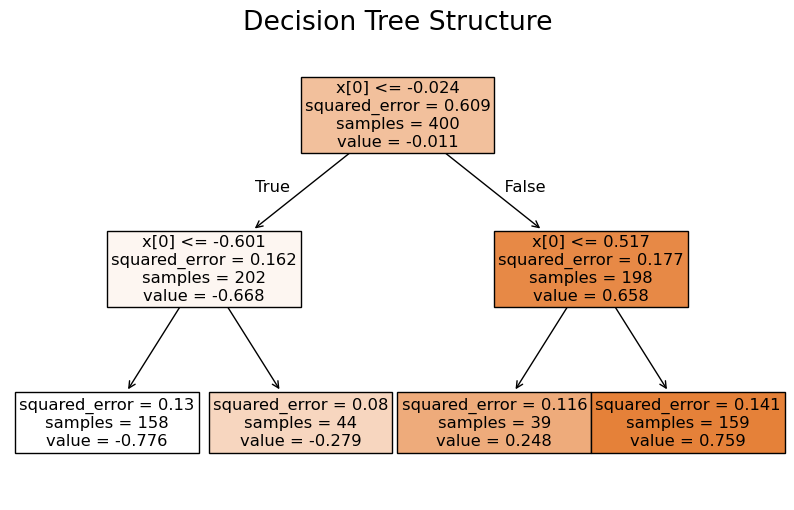

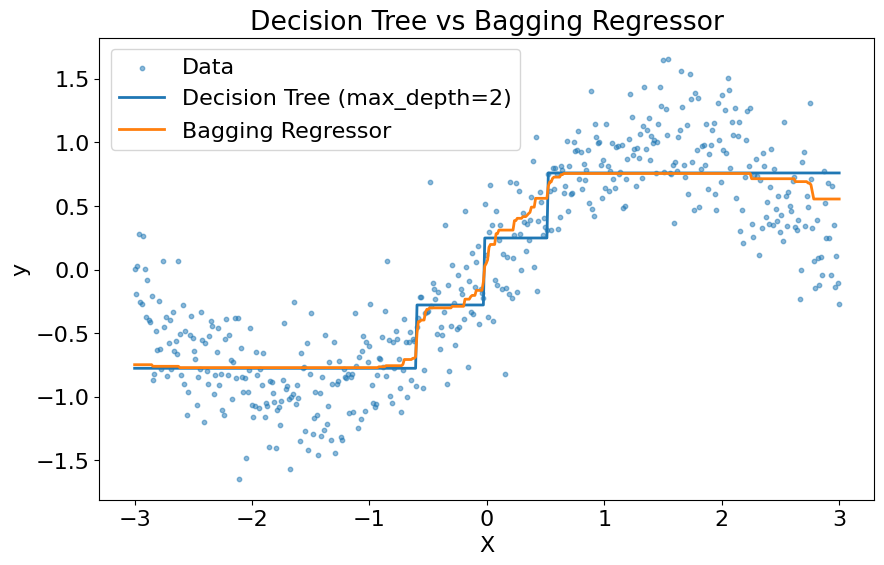

Decision Tree Test MSE: 0.14216003659637708
Bagging Regressor Test MSE: 0.13018951988027785


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

# Generate a synthetic dataset
np.random.seed(42)
X = np.linspace(-3, 3, 500)
y = np.sin(X) + np.random.normal(0, 0.3, X.shape[0])
X = X.reshape(-1, 1)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1. Decision Tree Regressor
tree_reg = DecisionTreeRegressor(max_depth=2, criterion="squared_error", random_state=42)
tree_reg.fit(X_train, y_train)

# Predictions with decision tree
y_train_pred_tree = tree_reg.predict(X_train)
y_test_pred_tree = tree_reg.predict(X_test)

# Plot the decision tree structure
plt.figure(figsize=(10,6))
plot_tree(tree_reg, filled=True)
plt.title("Decision Tree Structure")
plt.show()

# 2. Bagging Regressor using the same tree
bagging_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=2, criterion="squared_error"),
    n_estimators=50,
    random_state=42
)

bagging_reg.fit(X_train, y_train)

# Predictions with bagging
y_train_pred_bag = bagging_reg.predict(X_train)
y_test_pred_bag = bagging_reg.predict(X_test)

# Sort X values for smooth plotting
sort_idx = np.argsort(X.flatten())
X_sorted = X.flatten()[sort_idx]

tree_pred_sorted = tree_reg.predict(X)[sort_idx]
bag_pred_sorted = bagging_reg.predict(X)[sort_idx]

# 3. Plot fitted functions
plt.figure(figsize=(10,6))

# Original data
plt.scatter(X, y, s=10, alpha=0.5, label="Data")

# Decision Tree prediction
plt.plot(X_sorted, tree_pred_sorted, label="Decision Tree (max_depth=2)", linewidth=2)

# Bagging prediction
plt.plot(X_sorted, bag_pred_sorted, label="Bagging Regressor", linewidth=2)

plt.title("Decision Tree vs Bagging Regressor")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Compare errors
print("Decision Tree Test MSE:", mean_squared_error(y_test, y_test_pred_tree))
print("Bagging Regressor Test MSE:", mean_squared_error(y_test, y_test_pred_bag))

### Homework - Adaboost on the Adult Dataset (census Income) 

Use the Adult dataset to build an AdaBoost classifier that predicts whether an individual's income exceeds $50K/year based on their demographic and employment information. The dataset is already loaded.

1. Preprocess the dataset. Handle the missing values. For the numerical features apply the `StandardScaler` and for the categorical ones apply one-hot encoding. Create a train/test split with the ratio 80/20. (1 points)
2. Create an `AdaBoostClassifier`. The classifier has to use a `DecisionTreeClassifier` as an `estimator` with `max_depth=2`. Use `n_estimater=10`.   (1 point)
3. The ROC (Reciever Operating Characteristic) curve is widely used for the evaluation of binary classification problems. It is a plot of the TPR (True Positive Rate) as a function of FPR (False Positive Rate) as we change the threshold used for the final prediction (If the predicted probability is greater than or equal to the threshold, the instance is classified as positive; otherwise, it is classified as negative.). Plot the ROC curve of your estimator and calculate the AUC score , which is the area under the curve (there are built in functions for these). Find the optimal operating point of your classifier (the one closest to the top left point), what is the threshold in this case? Interpret your curve! (2 points).
5. Plot the precision-recall (PR) curve. The precision is the ratio of true positive predictions to the total number of positive predictions (true positives + false positives). The recall is the ratio of true positive predictions to the total number of actual positives (true positives + false negatives). Find the optimal operating ploint (closest to the top right corner), what is the threshold in this case? Interpret your result!  (2 points).
4. Plot the confusion matrix of your estimator using the threshold from the ROC and the threshold from the PR curve. Interpret your result, what are the advantages of the two classifiers? (2 point)
6. Plot the feature importance of your classifier as a bar plot (2 points).


In [34]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix, precision_recall_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
adult_data = fetch_openml(name='adult', version=2, as_frame=True)
X = adult_data.data
y = adult_data.target
